# Final Report - XGBoost

### Step 1: 載入資料與預處理
載入資料並進行訓練/測試集切分。**注意：本次實驗不使用 SMOTE。**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import warnings
import seaborn as sns

from IPython.display import display
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

# ── 1. 載入資料，排除序號欄 ────────────────────────────────
df = pd.read_csv('processed_data.csv')
df = df.drop(columns=['序號'])

# ── 2. 特徵與目標變數 ──────────────────────────────────────
X = df.drop(columns=['Y_事故嚴重度']).fillna(0)
y = df['Y_事故嚴重度']

features = X.columns.tolist()
print(f"特徵數量：{len(features)}")

# ── 3. 切分訓練集 / 測試集 ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"訓練集：{len(X_train)} 筆，測試集：{len(X_test)} 筆")
print(f"\n訓練集 Y 分布：\n{y_train.value_counts()}")
print(f"\n測試集 Y 分布：")
print(y_test.value_counts())
print(f"\n訓練集：{len(X_train)} 筆，測試集：{len(X_test)} 筆")

# Mac 內建的支援中文的字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
# 或者是 plt.rcParams['font.sans-serif'] = ['PingFang TC']

# 解決負號 ('-') 顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False

# Windows 使用微軟正黑體 (Mac 若需使用請改為 'Arial Unicode MS' 或 'PingFang TC')
# plt.rcParams['font.family'] = 'Microsoft JhengHei'
# plt.rcParams['axes.unicode_minus'] = False

特徵數量：54
訓練集：15329 筆，測試集：3833 筆

訓練集 Y 分布：
Y_事故嚴重度
1    8580
0    6749
Name: count, dtype: int64

測試集 Y 分布：
Y_事故嚴重度
1    2146
0    1687
Name: count, dtype: int64

訓練集：15329 筆，測試集：3833 筆


### Step 2: Modeling (建立模型與交叉驗證)
由於沒有使用 SMOTE，我們必須利用 XGBoost 的 `scale_pos_weight` 參數來處理資料不平衡。
`scale_pos_weight` 的建議設定值為：**負樣本數 / 正樣本數**。

In [3]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ── 1. 計算正負樣本比例 ────────────────────────────────────
# y_train 中 0 為非致命(負樣本)，1 為致命(正樣本)
neg_count = len(y_train[y_train == 0])
pos_count = len(y_train[y_train == 1])
sp_weight = neg_count / pos_count
print(f"計算得到的 scale_pos_weight: {sp_weight:.4f}")

# ── 2. 定義初步 XGBoost 模型 ─────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=sp_weight, # 設定權重以處理不平衡
    eval_metric='logloss',
    n_jobs=-1
)

# ── 3. 10-fold 交叉驗證 ────────────────────────────────────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_recall = cross_val_score(
    xgb_model, X_train, y_train, # 直接使用原始 X_train, y_train
    cv=cv, scoring='recall', n_jobs=-1
)

cv_f1 = cross_val_score(
    xgb_model, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print("\n【預設參數】10-fold 交叉驗證結果：")
print(f"  Recall : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"  F1     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# ── 4. 訓練模型 ─────────────────────────────────────────
xgb_model.fit(X_train, y_train)
print("\n初步 XGBoost 模型訓練完成！")

計算得到的 scale_pos_weight: 0.7866

【預設參數】10-fold 交叉驗證結果：
  Recall : 0.5378 ± 0.0111
  F1     : 0.5778 ± 0.0099

初步 XGBoost 模型訓練完成！


### Step 3: Hyperparameter Tuning (超參數調優)
使用 GridSearchCV 尋找最佳的 `n_estimators`、`max_depth` 與 `learning_rate`。
確保在參數網格中包含我們計算出的 `scale_pos_weight`。

In [4]:
from sklearn.model_selection import GridSearchCV

# ── 1. 定義 XGBoost 參數網格 ──────────────────────────────
param_grid_xgb = {
    # 樹的數量：搭配較低的學習率，慢慢學比較穩
    'n_estimators': [100, 200, 300], 
    
    # 樹的深度：通常 3~7 之間表現最好，不容易死背
    'max_depth': [4, 6, 8], 
    
    # 學習率：0.2 已經算高了，建議加上 0.1 甚至更低的選項
    'learning_rate': [0.05, 0.1, 0.2], 
    
    # 正樣本權重：除了算出來的值，可以稍微給點彈性讓模型試試看
    'scale_pos_weight': [sp_weight] 
}

# ── 2. Grid Search (10 折交叉驗證) ─────────────────────────
grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid_xgb,
    cv=10,              # 使用 10-fold CV
    scoring='recall',   # 以 Recall 作為主要優化目標
    n_jobs=-1,
    verbose=1           # 執行時會顯示進度資訊
)

grid_search_xgb.fit(X_train, y_train)

# ── 3. 整理與輸出結果 ─────────────────────────────────────
results_xgb = pd.DataFrame(grid_search_xgb.cv_results_)

summary_xgb = results_xgb[[
    'param_n_estimators', 'param_max_depth', 'param_learning_rate',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]]
summary_xgb = summary_xgb.rename(columns={
    'mean_test_score': 'Recall（平均）',
    'std_test_score': 'Recall（標準差）',
    'rank_test_score': '排名'
}).sort_values('排名')

print("\n超參數調優結果摘要 (前 5 名)：")
display(summary_xgb.head(5))

print(f"\n最佳參數：{grid_search_xgb.best_params_}")
print(f"最佳 Recall（10-CV）：{grid_search_xgb.best_score_:.4f}")

# ── 4. 取得最佳模型 ───────────────────────────────────────
best_xgb = grid_search_xgb.best_estimator_
print("\n最佳 XGBoost 模型準備完畢！")

Fitting 10 folds for each of 27 candidates, totalling 270 fits

超參數調優結果摘要 (前 5 名)：


,param_n_estimators,param_max_depth,param_learning_rate,Recall（平均）,Recall（標準差）,排名
26,300,8,0.2,0.599417,0.022139,1
25,200,8,0.2,0.593124,0.020761,2
17,300,8,0.1,0.588462,0.016528,3
23,300,6,0.2,0.578671,0.019588,4
16,200,8,0.1,0.578089,0.015550,5



最佳參數：{'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 300, 'scale_pos_weight': 0.7865967365967366}
最佳 Recall（10-CV）：0.5994

最佳 XGBoost 模型準備完畢！


### Step 4: Evaluation (模型評估)
在測試集上進行預測，並計算各項評估指標、分類報告以及繪製混淆矩陣。

指標                 XGBoost 最佳模型
Accuracy                 0.5531
Precision                0.5986
Recall                   0.6123
F1-score                 0.6054
ROC-AUC                  0.5712
PR-AUC                   0.6186

Classification Report:
              precision    recall  f1-score   support

     非致命 (0)       0.49      0.48      0.48      1687
      致命 (1)       0.60      0.61      0.61      2146

    accuracy                           0.55      3833
   macro avg       0.55      0.55      0.55      3833
weighted avg       0.55      0.55      0.55      3833



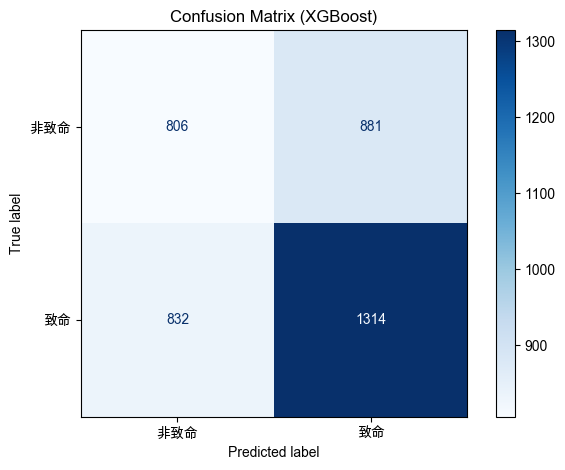

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── 1. 在測試集上進行預測 ─────────────────────────────────
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# ── 2. 指標輸出 ──────────────────────────────────────────
print("=" * 45)
print(f"{'指標':<15} {'XGBoost 最佳模型':>15}")
print("=" * 45)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred_xgb):>15.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred_xgb):>15.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred_xgb):>15.4f}")
print(f"{'F1-score':<15} {f1_score(y_test, y_pred_xgb):>15.4f}")
print(f"{'ROC-AUC':<15} {roc_auc_score(y_test, y_prob_xgb):>15.4f}")
print(f"{'PR-AUC':<15} {average_precision_score(y_test, y_prob_xgb):>15.4f}")
print("=" * 45)

# ── 3. 分類報告 ──────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['非致命 (0)', '致命 (1)']))

# ── 4. 混淆矩陣 (Confusion Matrix) ────────────────────────
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['非致命', '致命'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (XGBoost)')
plt.tight_layout()
plt.show()

### Step 5: Interpretation (模型解釋 - SHAP)
利用 SHAP (SHapley Additive exPlanations) 來拆解 XGBoost 模型，觀察特徵的全局重要性與單一案例的判斷邏輯。

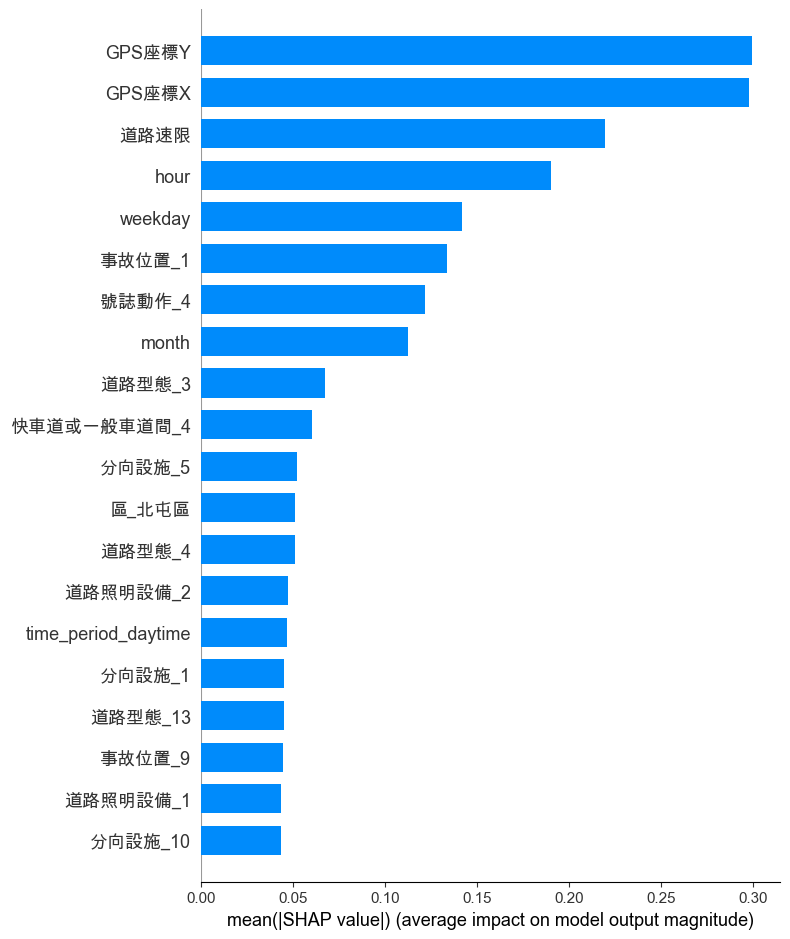

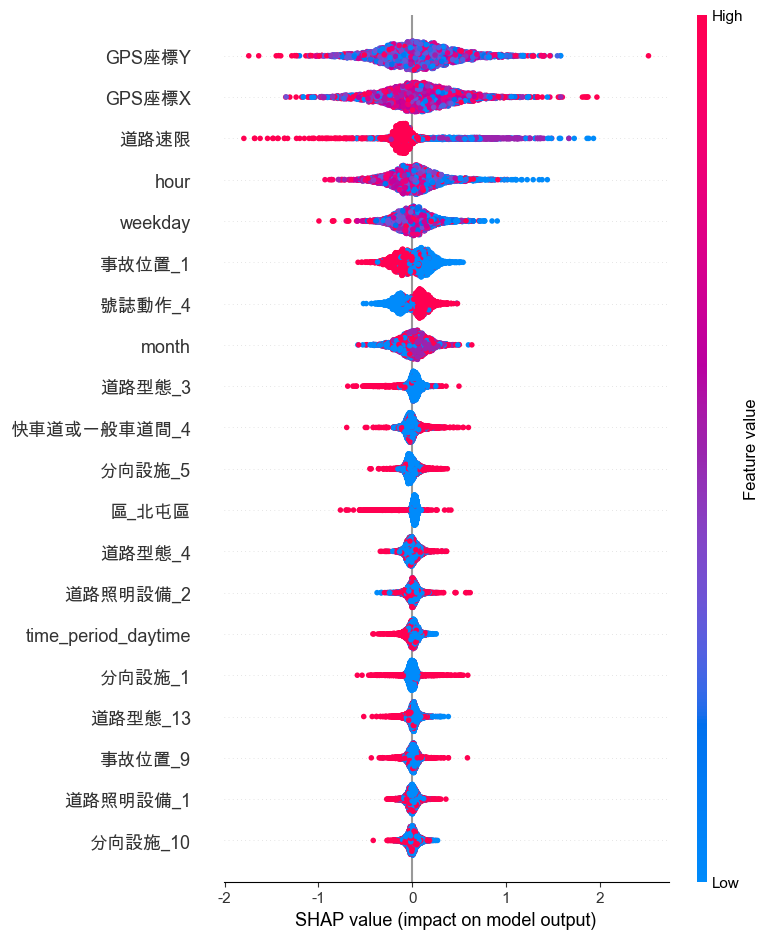

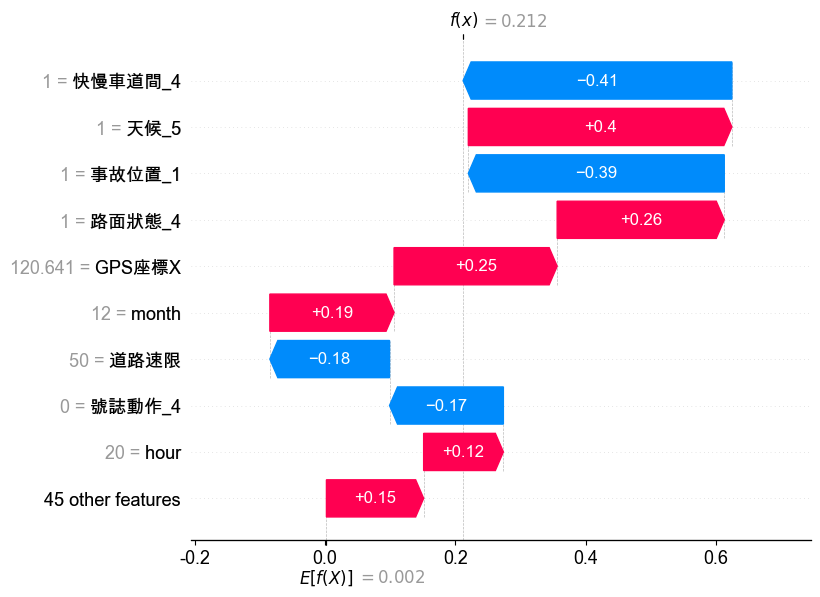

In [6]:
import shap

# ── 1. 建立 SHAP Explainer ────────────────────────────────
# XGBoost 屬於樹狀模型，使用 TreeExplainer
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# ── 2. Summary Bar Plot：全局特徵重要性 ──────────────────
shap.summary_plot(
    shap_values_xgb, X_test,
    feature_names=features,
    plot_type='bar',
    show=True
)

# ── 3. Beeswarm Plot：特徵影響方向 ───────────────────────
shap.summary_plot(
    shap_values_xgb, X_test,
    feature_names=features,
    show=True
)

# ── 4. Waterfall Plot：單一致命案例解析 ──────────────────
# 找出測試集中第一筆實際為「致命」(1) 的資料索引
fatal_idx = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_xgb[fatal_idx],
        base_values=explainer_xgb.expected_value,
        data=X_test.iloc[fatal_idx],
        feature_names=features
    )
)

In [7]:
import numpy as np
import pandas as pd

# 1. 取得新進資料預測為「嚴重事故 (1)」的機率
# 假設 best_xgb 是您訓練好的模型，X_new 是即時的交通事故特徵
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# 2. 設定您的閾值 (Thresholds)
high_thresh = 0.7
med_thresh = 0.3

# 3. 定義邏輯條件與對應的策略
conditions = [
    (y_prob >= high_thresh),
    (y_prob >= med_thresh) & (y_prob < high_thresh),
    (y_prob < med_thresh)
]

risk_tiers = ['高風險', '中風險', '低風險']
actions = ['優先派遣警力或加強巡邏', '定期巡查', '維持現狀']

# 4. 產出決策報表
df_decisions = pd.DataFrame({'嚴重事故預測機率': y_prob})

# 加上 default='未知' 或其他字串，讓 NumPy 知道遇到例外時該填什麼字串
df_decisions['風險等級'] = np.select(conditions, risk_tiers, default='未知')
df_decisions['決策策略'] = np.select(conditions, actions, default='無動作')

# 檢視高風險且需要立即派警力的清單，並依機率高低排序
df_dispatch = df_decisions[df_decisions['風險等級'] == '高風險'].sort_values(by='嚴重事故預測機率', ascending=False)
display(df_dispatch.head(100))

,嚴重事故預測機率,風險等級,決策策略
3089,0.998885,高風險,優先派遣警力或加強巡邏
2259,0.998456,高風險,優先派遣警力或加強巡邏
502,0.996804,高風險,優先派遣警力或加強巡邏
2929,0.994156,高風險,優先派遣警力或加強巡邏
2570,0.994113,高風險,優先派遣警力或加強巡邏
...,...,...,...
3325,0.956333,高風險,優先派遣警力或加強巡邏
1803,0.956247,高風險,優先派遣警力或加強巡邏
1859,0.955799,高風險,優先派遣警力或加強巡邏
3676,0.955269,高風險,優先派遣警力或加強巡邏


## Step 6：模型預測結果

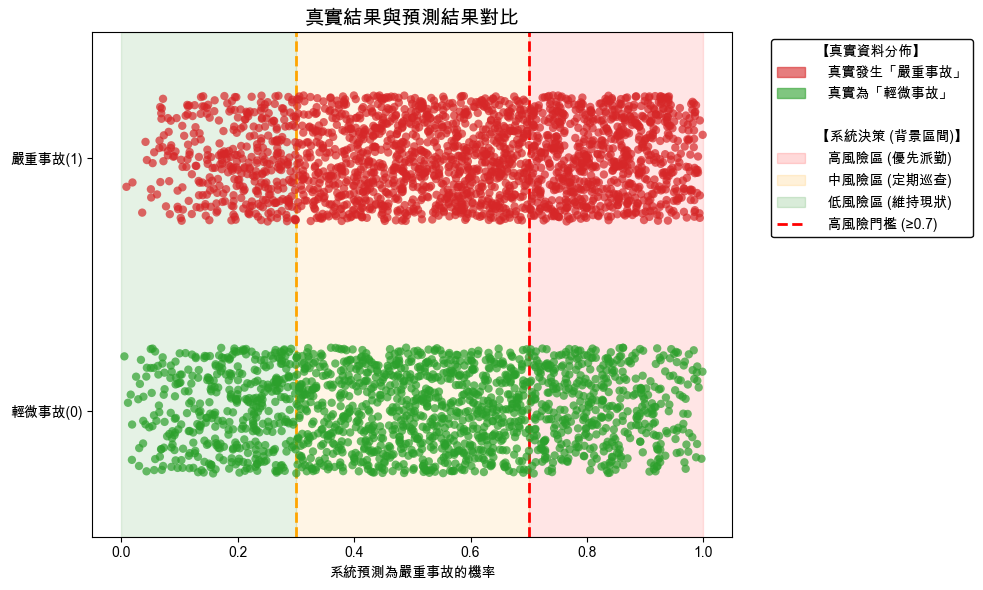

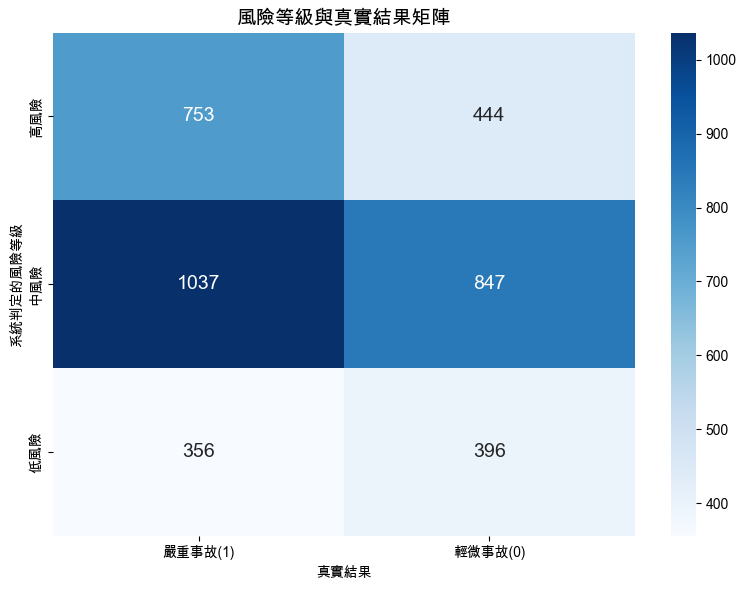


【案件決策與真實情況比對表 (依高風險排序)】


,嚴重事故預測機率,風險等級,決策策略,真實結果標籤
10045,0.998885,高風險,優先派遣警力,嚴重事故(1)
5751,0.998456,高風險,優先派遣警力,輕微事故(0)
11005,0.996804,高風險,優先派遣警力,輕微事故(0)
4621,0.994156,高風險,優先派遣警力,嚴重事故(1)
10295,0.994113,高風險,優先派遣警力,嚴重事故(1)
5992,0.993959,高風險,優先派遣警力,嚴重事故(1)
5766,0.993341,高風險,優先派遣警力,嚴重事故(1)
11650,0.992035,高風險,優先派遣警力,輕微事故(0)
11293,0.990899,高風險,優先派遣警力,嚴重事故(1)
9679,0.990844,高風險,優先派遣警力,嚴重事故(1)


In [9]:
# 設定支援中文的字體 (依您的作業系統調整，Windows通常用 'Microsoft JhengHei')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 取得預測機率
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# 2. 產出決策報表：新增「真實結果」欄位
df_decisions = pd.DataFrame({
    '嚴重事故預測機率': y_prob,
    '真實結果': y_test.values  # 放入真實的 0 或 1
}, index=y_test.index) # 保留原本測試集的 index 方便後續查閱異常案件

# 3. 設定閾值與決策邏輯
high_thresh = 0.7
med_thresh = 0.3

conditions = [
    (df_decisions['嚴重事故預測機率'] >= high_thresh),
    (df_decisions['嚴重事故預測機率'] >= med_thresh) & (df_decisions['嚴重事故預測機率'] < high_thresh),
    (df_decisions['嚴重事故預測機率'] < med_thresh)
]
risk_tiers = ['高風險', '中風險', '低風險']
actions = ['優先派遣警力', '定期巡查', '維持現狀']

df_decisions['風險等級'] = np.select(conditions, risk_tiers, default='未知')
df_decisions['決策策略'] = np.select(conditions, actions, default='無動作')
df_decisions['真實結果標籤'] = df_decisions['真實結果'].map({1: '嚴重事故(1)', 0: '輕微事故(0)'})


# ================= 視覺化圖表繪製 (圖表一) =================
# 建立第一張圖：獨立的機率分佈散點圖
plt.figure(figsize=(10, 6))

sns.stripplot(data=df_decisions, x='嚴重事故預測機率', y='真實結果標籤', 
              hue='真實結果標籤', 
              palette={'嚴重事故(1)': '#d62728', '輕微事故(0)': '#2ca02c'}, 
              order=['嚴重事故(1)', '輕微事故(0)'], 
              jitter=0.25, alpha=0.7, size=6, legend=False)

# 畫上決策門檻虛線
plt.axvline(high_thresh, color='red', linestyle='--', linewidth=2)
plt.axvline(med_thresh, color='orange', linestyle='--', linewidth=2)

# 填滿背景風險區塊顏色 (視覺化紅黃綠區)
plt.axvspan(high_thresh, 1.0, color='red', alpha=0.1)       
plt.axvspan(med_thresh, high_thresh, color='orange', alpha=0.1) 
plt.axvspan(0.0, med_thresh, color='green', alpha=0.1)      

# 建立階層式的完美圖例說明
legend_elements = [
    mlines.Line2D([], [], color='none', label='【真實資料分佈】'),
    mpatches.Patch(color='#d62728', alpha=0.6, label='   真實發生「嚴重事故」'),
    mpatches.Patch(color='#2ca02c', alpha=0.6, label='   真實為「輕微事故」'),
    mlines.Line2D([], [], color='none', label=' '),
    mlines.Line2D([], [], color='none', label='【系統決策 (背景區間)】'),
    mpatches.Patch(color='red', alpha=0.15, label='   高風險區 (優先派勤)'),
    mpatches.Patch(color='orange', alpha=0.15, label='   中風險區 (定期巡查)'),
    mpatches.Patch(color='green', alpha=0.15, label='   低風險區 (維持現狀)'),
    mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label=f'   高風險門檻 (≥{high_thresh})'),
]

# 將圖例放置於圖表「外側」右上方 (bbox_to_anchor 控制位置)
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
           fontsize=10, title='', title_fontsize=12, framealpha=0.95, edgecolor='black', labelspacing=0.5)

plt.title('真實結果與預測結果對比', fontsize=14, fontweight='bold')
plt.xlabel('系統預測為嚴重事故的機率')
plt.ylabel('') 
plt.tight_layout()
plt.show()


# ================= 視覺化圖表繪製 (圖表二) =================
# 建立第二張圖：獨立的熱力圖
plt.figure(figsize=(8, 6))

crosstab = pd.crosstab(df_decisions['風險等級'], df_decisions['真實結果標籤'])
crosstab = crosstab.reindex(['高風險', '中風險', '低風險'])

sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14})
plt.title('風險等級與真實結果矩陣', fontsize=14, fontweight='bold')
plt.xlabel('真實結果')
plt.ylabel('系統判定的風險等級')

plt.tight_layout()
plt.show()


# ================= 預測結果與真實情況明細表 =================
print("\n【案件決策與真實情況比對表 (依高風險排序)】")
# 整理欲輸出的欄位
df_summary = df_decisions[['嚴重事故預測機率', '風險等級', '決策策略', '真實結果標籤']].copy()
# 依照危險程度由高至低排序
df_summary = df_summary.sort_values(by='嚴重事故預測機率', ascending=False)

# 顯示前 15 筆
display(df_summary.head(15))

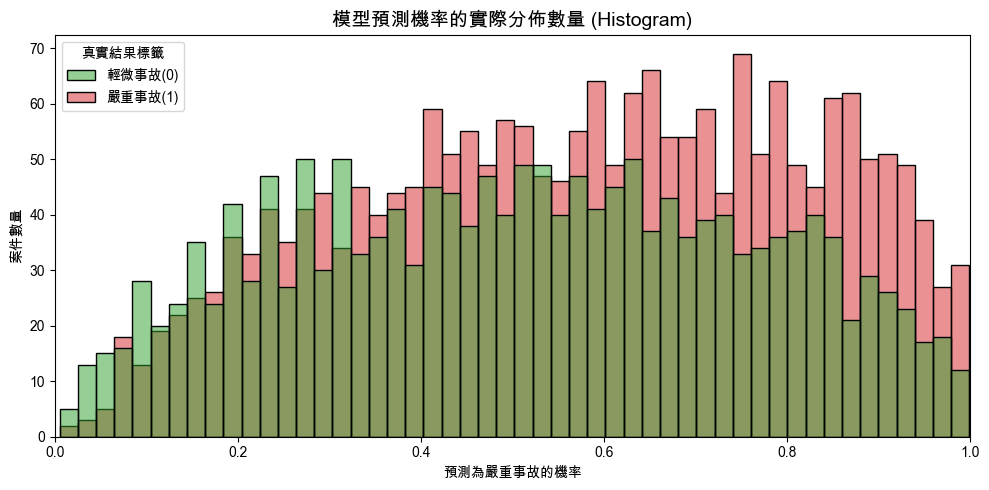

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# 畫出 0 到 1 之間的機率分佈，切成 50 個區塊 (bins)
sns.histplot(data=df_decisions, x='嚴重事故預測機率', hue='真實結果標籤', 
             bins=50, kde=False, palette={'嚴重事故(1)': '#d62728', '輕微事故(0)': '#2ca02c'})

plt.title('模型預測機率的實際分佈數量 (Histogram)', fontsize=14)
plt.xlabel('預測為嚴重事故的機率')
plt.ylabel('案件數量')
plt.xlim(0, 1) # 強制 X 軸顯示 0 到 1
plt.tight_layout()
plt.show()